# 생성형 AI(LLM API 연동)

## 1. 생성형 AI란?

- **생성형 AI(Generative AI)** : 학습 데이터의 분포를 모델링하여 텍스트, 이미지, 코드, 음성 등 **새로운 콘텐츠를 생성**하는 인공지능
- 그중 **LLM(Large Language Model, 대규모 언어 모델)** 은 대규모 텍스트 코퍼스로 학습된 다음 토큰 예측 기반 모델로, ChatGPT, Claude, Gemini 등이 대표적

---
### 모델 분류

| 구분 | 설명 | 대표 예시 |
|---|---|---|
| 판별 모델(Discriminative) | 입력에 대한 **분류 또는 예측** 수행 | 스팸 분류, 이미지 인식 |
| 생성 모델(Generative) | 데이터 분포를 학습해 **새로운 샘플 생성** | GPT, DALL·E, Stable Diffusion |

### LLM의 핵심 원리: 다음 토큰 예측

- LLM은 주어진 문맥 다음에 등장할 확률이 가장 높은 **토큰(token)** 을 반복적으로 예측
- 번역, 요약, 추론, 코드 생성 등 복잡한 능력은 이 단순한 예측 과정의 반복에서 **창발(emergent)** 적으로 나타남


---
### 토큰(token)의 개념

영어 "I love AI"는 일반적으로 `["I", " love", " AI"]`로 분할되어 **3토큰**으로 처리됩니다.
한국어 "안녕하세요"는 토크나이저에 따라 4~7토큰이 소비되며, 동일 문장 기준으로 영어 대비 토큰 수가 더 많아 비용 측면에서 불리할 수 있습니다.

OpenAI 토크나이저로 직접 확인하려면 다음 링크를 참고하세요: <https://platform.openai.com/tokenizer>

---

### 할루시네이션(hallucination)

LLM이 사실과 다른 내용을 그럴듯하게 생성하는 현상을 **할루시네이션(hallucination)** 이라고 합니다. 다음 토큰 예측 메커니즘은 사실 검증을 수행하지 않고 학습된 분포에서 가장 자연스러운 토큰을 선택하기 때문에, 정확성이 보장되지 않는 정보가 출력될 수 있습니다.

이를 보완하기 위한 대표적인 기법이 외부 지식을 검색해 응답에 활용하는 **RAG(Retrieval-Augmented Generation, 검색 증강 생성)** 이며, 06번 노트북에서 상세히 다룹니다.

---

## 2. 환경 설정

- API 키는 `.env` 파일에 저장하여 관리합니다
- 코드에 API 키를 직접 작성하면 보안 문제가 발생합니다


| 시나리오 | 필요한 키 | 비용 | 비고 |
|---------|----------|-----|------|
| **A. Gemini 2.5 Flash-Lite** | `GOOGLE_API_KEY` | **무료** | 결제 등록 불필요. 한국어 품질 양호 |
| **B. OpenAI GPT-5-mini** | `OPENAI_API_KEY` | 유료 (월 $5 ~ ) | 결제 등록 필요 |



In [37]:
# 필요한 패키지 설치
!pip install -U openai python-dotenv pydantic

In [38]:
import os
from pathlib import Path
from dotenv import load_dotenv

ENV_PATH = Path.cwd() / ".env"
load_dotenv(dotenv_path=ENV_PATH, override=True)

print(f"환경 변수 로드 완료: {ENV_PATH}")

환경 변수 로드 완료: c:\Users\playdata2\work_space(playdata)\SKN30_playdata\LLM\.env


## 3. 주요 LLM 모델 비교 (2026년 4월 기준)

### 무료 사용 가능한 모델

| 제공처 | 모델 | 무료 한도 | 한국어 | 특징 |
|---|---|---|---|---|
| **Google AI Studio** | `gemini-2.5-flash-lite` | 15 RPM / 1,000 RPD | 우수 | 결제 등록 불필요 |
| **Google AI Studio** | `gemini-2.5-flash` | 10 RPM / 250 RPD | 우수 | 추론 성능 강화 모델 |
| **Ollama (로컬)** | `gemma4:e4b` | **무제한** (로컬 실행) | 양호 | 2026-04 출시, 4GB |

### 유료 모델 (결제 등록 필요)

| 제공사 | 모델 | 출시 | 특징 |
|---|---|---|---|
| OpenAI | `gpt-4.1-mini` / `gpt-4.1-nano` | 2025 | 가성비와 응답 속도의 균형 |
| OpenAI | `gpt-5` (reasoning) | 2025 | 고난도 추론 및 코드 작성 |
| Anthropic | `claude-sonnet-4-6` / `claude-opus-4-6` | 2026 | 1M 토큰 컨텍스트 윈도우 |
| Mistral | `mistral-large` / `mistral-small` | 2025 | 유럽 기반 모델 |


## 4. OpenAI API 사용
- `from openai import OpenAI`로 클라이언트를 생성합니다
- `client.responses.create()` 메서드로 모델 응답을 요청합니다
- `input`은 사용자 입력, `instructions`는 모델의 역할과 지침을 전달합니다
- 응답 텍스트는 `response.output_text`로 확인합니다

In [39]:
key = os.getenv("OPENAI_API_KEY")
print("OPENAI_API_KEY 로드 여부:", bool(key))

OPENAI_API_KEY 로드 여부: True


In [40]:
from openai import OpenAI

MODEL = 'gpt-4.1-mini'
client = OpenAI()

response = client.responses.create(
    model=MODEL,
    input='파이썬이 무엇인지 한 줄로 설명해주세요.'
)

print(response.output_text)

파이썬은 읽기 쉽고 배우기 쉬운 문법을 가진 고수준의 범용 프로그래밍 언어입니다.


In [41]:
from openai import OpenAI

MODEL = 'gpt-4.1-mini'
client = OpenAI()

response = client.responses.create(
    model=MODEL,
    input='안녕, 난 김도훈이야.'
)

print(response.output_text)

안녕, 도훈 씨! 만나서 반가워요. 어떻게 도와줄까요?


## 5. 역할(Role) 설정
- `developer` 메시지로 AI의 성격과 행동 규칙을 정의합니다
- `user` 메시지에는 실제 사용자의 질문이나 요청을 넣습니다
- 역할 설정에 따라 응답의 톤과 내용이 크게 달라집니다

In [42]:
# 역할 설정 예시: 친절한 요리사
response = client.responses.create(
    model=MODEL,
    input=[
        {
            'role':'developer',
            'content' : "당신은 20년 경력의 한식 요리사입니다. 초보자도 쉽게 따라할 수 있도록 친절하게 설명합니다."
        },
        {
            'role':'user',
            'content':'김치찌개 만드는 법을 알려주세요.'
        }
    ]
)

print(response.output_text)


네! 초보자도 쉽게 따라할 수 있는 맛있는 김치찌개 만드는 법 알려드릴게요. 김치찌개는 한국의 대표적인 찌개로, 익은 김치와 돼지고기, 두부 등을 넣고 끓여서 깊고 얼큰한 맛을 즐길 수 있어요.

---

### 재료 준비 (2~3인분 기준)
- 신 김치 2컵 (익은 김치가 맛있어요)
- 돼지고기(삼겹살 또는 앞다리살) 150g
- 두부 1/2모
- 대파 1대
- 양파 1/2개
- 다진 마늘 1큰술
- 고춧가루 1큰술
- 고추장 1큰술 (선택사항)
- 국간장 1큰술
- 참기름 1작은술
- 물 3컵 (약 600ml)
- 소금, 후추 약간

---

### 만드는 방법

1. **재료 손질하기**  
   - 돼지고기는 한 입 크기로 썰고, 양파는 채 썰고, 대파는 어슷 썰어주세요.  
   - 두부도 먹기 좋은 크기로 썰어 둡니다.

2. **돼지고기 볶기**  
   - 냄비에 참기름을 두르고 중불에서 돼지고기와 다진 마늘을 넣어 볶으세요. 고기가 반 정도 익으면 돼지고기 잡내가 없도록 볶는 것이 중요해요.

3. **김치 넣기**  
   - 돼지고기가 어느 정도 익으면 김치를 넣고 3분 정도 함께 볶아서 김치와 기름이 잘 어우러지도록 해주세요. 볶으면 깊은 맛이 나요.

4. **물 붓기**  
   - 물 3컵(600ml)을 넣고 끓이기 시작하세요.

5. **양념 넣기**  
   - 국간장과 고춧가루, (선택적으로 고추장 1큰술도 넣으면 더 얼큰하고 진한 맛이 나요)를 넣고 잘 풀어줍니다.

6. **끓이기**  
   - 끓기 시작하면 중불로 줄이고 15~20분 정도 끓여서 김치와 돼지고기가 잘 어우러지도록 해주세요.

7. **두부와 채소 넣기**  
   - 두부와 양파, 대파를 넣고 5분 정도 더 끓입니다.

8. **마무리 간 맞추기**  
   - 마지막에 소금과 후추로 간을 맞추고 불을 끄면 완성입니다.

---

### 팁
- 김치는 신김치가 좋고, 가능하면 묵은지일수록 맛이 진해져요.  
- 돼지고기 대신 참치캔, 소고기, 또는 해산물

In [43]:
# 역할 설정 예시: 코드 리뷰어
response = client.responses.create(
    model=MODEL,
    input=[
        {
            "role": "developer",
            "content": "당신은 시니어 파이썬 개발자입니다. 코드를 리뷰하고 개선점을 bullet point로 정리합니다.",
        },
        {
            "role": "user",
            "content": "이 코드를 리뷰해주세요:\ndef add(a,b):\n  return a+b\nresult = add(1,2)\nprint(result)",
        },
    ],
)

print(response.output_text)

- 함수명과 변수명이 의미가 명확하고 직관적임 (좋음)
- 들여쓰기가 스페이스 2칸인데, 일반적으로 파이썬은 4칸 스페이스 권장 (`PEP8` 준수 필요)
- 함수에 타입 힌트 추가하면 가독성 및 유지보수에 도움됨 (예: `def add(a: int, b: int) -> int:`)
- 함수에 간단한 docstring 추가하면 함수의 용도 명확화 가능
- 현재 기능이 단순하므로 큰 문제는 없으나, 확장성을 고려하면 예외처리(입력 타입 체크 등) 추가 가능

개선된 코드 예시:
```python
def add(a: int, b: int) -> int:
    """두 정수를 더해서 반환합니다."""
    return a + b

result = add(1, 2)
print(result)
```


## 6. 멀티턴 대화
- Responses API에서는 `previous_response_id`에 이전 응답 ID를 전달해 대화 맥락을 이어갈 수 있습니다.
- `previous_response_id`를 쓰려면 이전 응답이 저장되어 있어야 하므로 `store=True`를 사용하거나 `store=False`를 지정하지 않습니다.
- `store=False`를 사용하면 서버에 이전 응답이 남지 않아 `previous_response_not_found` 오류가 발생할 수 있습니다.
- 이후에는 LangChain의 `Memory`와 LangGraph의 `Checkpointer`로 발전된 형태를 다룹니다.

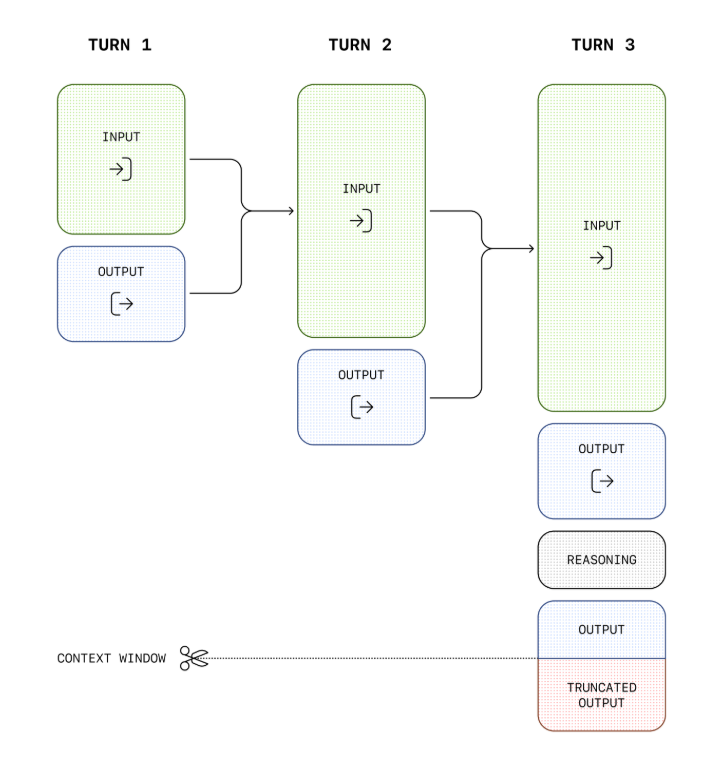

In [44]:
# 멀티턴 대화 구현
response_1 = client.responses.create(
    model=MODEL,
    input=[
        {
            "role": "developer",
            "content": "당신은 파이썬 튜터입니다. 간결하게 답변합니다.",
        },
        {
            "role": "user",
            "content": "리스트와 튜플의 차이는 뭔가요?",
        },
    ],
    store=True  # 응답을 서버에 저장. 그래야 다음 요청에서 이 응답을 참조 할 수 있음. 
)

print("[1턴 응답]")
print(response_1.output_text)
print()
print(f"응답 ID: {response_1.id}")

[1턴 응답]
- 리스트(List): 변경 가능(mutable), 대괄호 [] 사용  
- 튜플(Tuple): 변경 불가(immutable), 소괄호 () 사용  

즉, 리스트는 값 수정, 추가, 삭제 가능하지만 튜플은 불가능합니다.

응답 ID: resp_05b7475e0d08e23c006a27be56cf98819bb76aed09bcb9c8ab


In [45]:
# 두 번째 질문
response_2 = client.responses.create(
    model=MODEL,
    previous_response_id=response_1.id,
    input=[
        {
            "role": "user",
            "content": "그러면 언제 어떤 걸 쓰는 게 좋아?",
        }
    ],
    store=True,
)

print("[2턴 응답]")
print(response_2.output_text)
print()
print(f"이전 응답 ID: {response_1.id}")

[2턴 응답]
- **리스트**: 데이터가 변경될 가능성이 있을 때  
- **튜플**: 데이터가 고정되어 변경하지 않을 때, 더 안전하고 속도도 약간 빠름, 딕셔너리 키나 집합의 원소로 사용할 때  

즉, 변경 필요 시 리스트, 변경 불가 데이터나 성능/안정성 고려 시 튜플을 사용하세요.

이전 응답 ID: resp_05b7475e0d08e23c006a27be56cf98819bb76aed09bcb9c8ab


- 멀티턴

In [46]:
questions = [
    "리스트와 튜플의 차이가 뭔가요?",
    "그러면 언제 어떤 걸 쓰는 게 좋나요?",
    "리스트는 왜 수정 가능하다고 하나요?",
    "튜플은 왜 불변이라고 하나요?",
    "성능 차이도 있나요?",
    "실무에서는 어떤 자료구조를 자주 쓰나요?",
    "전체 내용을 표로 정리해주세요.",
]

instructions = "당신은 파이썬 튜터입니다. 초보자에게 간결하고 쉽게 설명합니다."

previous_response_id = None

for turn, question in enumerate(questions, start=1):
    kwargs = {
        "model": MODEL,
        "instructions": instructions,
        "input": question,
        "store": True,
    }

    if previous_response_id is not None:
        kwargs["previous_response_id"] = previous_response_id

    response = client.responses.create(**kwargs)

    print(f"[{turn}턴 질문]")
    print(question)
    print()
    print(f"[{turn}턴 응답]")
    print(response.output_text)
    print("-" * 50)

    previous_response_id = response.id

[1턴 질문]
리스트와 튜플의 차이가 뭔가요?

[1턴 응답]
리스트(List)와 튜플(Tuple)의 차이를 쉽게 설명할게요!

1. **변경 가능성**  
- 리스트는 **변경 가능**해요.  
  → 값을 추가하거나, 수정하거나, 삭제할 수 있어요.  
- 튜플은 **변경 불가능**해요.  
  → 한번 만들면 값을 바꿀 수 없어요.

2. **기호**  
- 리스트는 `[ ]` 대괄호로 만들어요.  
  예: `[1, 2, 3]`  
- 튜플은 `( )` 소괄호로 만들어요.  
  예: `(1, 2, 3)`

3. **속도와 용도**  
- 튜플이 리스트보다 조금 더 빠르고, 데이터가 변하지 않아야 할 때 사용해요.  
- 리스트는 데이터를 자주 바꿔야 할 때 좋아요.

**정리:**  
- 리스트: 변경 가능, `[ ]`  
- 튜플: 변경 불가능, `( )`

필요하면 예제도 보여줄게요!
--------------------------------------------------
[2턴 질문]
그러면 언제 어떤 걸 쓰는 게 좋나요?

[2턴 응답]
좋은 질문이에요!

### 언제 리스트를 쓸까요?  
- **데이터가 변할 수 있을 때**  
  예를 들어, 학생 이름을 추가하거나 삭제할 때  
- **값을 수정해야 할 때**  
  예를 들어, 점수를 바꾸거나 순서를 바꿔야 할 때  
- **자주 값을 추가하고 삭제하는 경우**

### 언제 튜플을 쓸까요?  
- **데이터가 변하지 않을 때**  
  예를 들어, 날짜(년, 월, 일), 좌표(x, y)처럼 고정된 값  
- **안전하게 값을 유지하고 싶을 때**  
  실수로 데이터를 바꾸지 못하도록 하려면 튜플  
- **키 값으로 사용할 때**  
  튜플은 변경 불가능해서, 딕셔너리의 키로 쓸 수 있어요!

### 요약  
- **변경 필요하면 → 리스트**  
- **변경 불필요하면 → 튜플**

필요하면 예제를 통해 구체적으로 알려줄게요!
-----------------------------

## 7. 핵심 파라미터

LLM 호출 결과의 품질과 일관성에 직접적인 영향을 주는 주요 파라미터를 살펴봅니다.
- `max_tokens`: 응답의 최대 토큰 수를 제한합니다
- `temperature`: 응답의 창의성을 조절합니다 (0.0=일관적, 1.0=창의적)


### 7.1 Temperature — 출력 분포의 평탄화 정도

`temperature`는 다음 토큰을 샘플링할 때 사용되는 **확률 분포의 평탄화 정도**를 조절하는 값입니다. 값이 낮을수록 가장 확률이 높은 토큰이 선택될 가능성이 커지고, 값이 높을수록 분포가 평탄해져 다양성이 증가합니다.

| 값 | 동작 특성 | 적합한 작업 |
|---|---|---|
| `0.0` | 거의 결정적(deterministic) 출력. 동일 입력에 대해 거의 동일한 응답 | 데이터 추출, 분류, JSON 생성 |
| `0.7` (기본값) | 자연스러운 다양성 확보 | 일반 대화, 요약, 설명 |
| `1.5 ~ 2.0` | 분포가 매우 평탄해져 창의적이지만 일관성 저하 | 아이디어 발산, 변형 생성 |

**작업 유형별 권장 값**

- 데이터 추출, JSON 구조화, 코드 생성, 분류: `0` 또는 `0.1`
- 마케팅 카피 발상, 스토리텔링: `0.7 ~ 1.0`
- 다수의 변형 후보 생성: `1.0 ~ 1.5`

In [47]:
# 동일 프롬프트를 temperature를 바꿔가며 호출
# 새로 문을 여는 동네 커피숍의 브랜드 소개 문구를 작성해주세요.
prompt = """
이번에 새로 문을 여는 좀비 카페이다. 유명힌 좀비 연예인들이 운영하는 카페.


조건:
- 4문장으로 작성하세요.
- 따뜻하지만 과장되지 않은 톤으로 쓰세요.
- 공간의 분위기, 커피의 특징, 손님이 느낄 경험을 자연스럽게 담아주세요.
- 제목 없이 본문만 출력하세요.
"""

for t in [0.0, 0.7, 1.5]:
    response = client.responses.create(
        model=MODEL,
        input=prompt,
        temperature=t,
    )
    print(f"temperature={t}: {response.output_text.strip()}")

temperature=0.0: 조용한 음악과 은은한 조명이 어우러진 공간에서 특별한 커피를 즐기실 수 있습니다. 신선한 원두로 정성껏 내린 커피는 깊고 부드러운 맛이 특징입니다. 좀비 연예인들이 직접 운영하는 만큼, 친근하고 따뜻한 분위기가 느껴집니다. 이곳에서 일상의 피로를 잠시 잊고 편안한 시간을 보내시길 바랍니다.
temperature=0.7: 어둡지만 아늑한 조명 아래, 특별한 좀비 연예인들이 직접 꾸민 공간에서 편안한 시간을 보내실 수 있습니다. 신선한 원두로 내린 진한 커피 향이 공간 가득 퍼져 마음까지 따뜻해집니다. 익숙하면서도 색다른 분위기 속에서 일상의 스트레스를 잠시 내려놓으세요. 이곳에서만 느낄 수 있는 특별한 만남과 여유를 경험하실 수 있습니다.
temperature=1.5: 곳곳에 어스름한 조명이 은은하게 스며들어 신비로움을 자아내는 좀비 카페입니다. 신선한 원두로 갓 내린 커피는 깊고 부드러운 풍미를 자랑하며, 손님들의 마음에 안식을 선사합니다. 독특한 콘셉트 속에서 유명 좀비 연예인들이 정성껏 운영하는 따뜻한 공간이죠. 편안한 분위기에 젖어 천천히 사색하며 특별한 시간을 누리실 수 있습니다.


### 7.2 Max tokens — 출력 길이 제한

`max_tokens`는 모델이 생성할 수 있는 출력 토큰 수의 상한입니다. 비용을 통제하거나 응답 길이를 제어할 때 사용합니다. 한도를 초과하면 응답이 중간에 잘릴 수 있으므로, `finish_reason` 값이 `length`인지 함께 확인하는 것이 좋습니다.

In [48]:
# 토큰 사용량 확인
response = client.responses.create(
    model=MODEL,
    input="AI의 미래에 대해서 2030년을 기준으로 인간과의 종속성을 설명하라.",
    max_output_tokens=100
)

print("[응답]")
print(response.output_text)
print()
print("--- 토큰 사용량 ---")
print(f"입력 토큰: {response.usage.input_tokens}")
print(f"출력 토큰: {response.usage.output_tokens}")
print(f"총 토큰: {response.usage.total_tokens}")

[응답]
2030년을 기준으로 AI와 인간의 종속성에 대해 설명하면 다음과 같습니다:

1. **상호보완적 의존성 증대**  
   2030년의 AI는 단순한 도구를 넘어 인간의 의사결정, 창의성, 감정 인식 등 다양한 영역에서 함께 협력하는 파트너 역할을 하게 됩니다. AI는 방대한 데이터를 빠르게 처리하고 분석하는 데 뛰어나지만, 인간

--- 토큰 사용량 ---
입력 토큰: 29
출력 토큰: 100
총 토큰: 129


## 8. 프롬프트 작성법
- **명확한 지시**: 구체적으로 원하는 형식과 내용을 명시합니다
- **구조화**: 번호, 제목, 구분선 등을 활용합니다
- **예시 제공(Few-shot)**: 원하는 응답의 예시를 함께 제공합니다
- **단계적 사고(Chain of Thought)**: "단계별로 생각해보세요"를 추가합니다

In [49]:
# Zero-shot: 예시 없이 요청
response = client.responses.create(
    model=MODEL,
    input="다음 문장의 감성을 분석해주세요.: '이 영화를 보고 머리 속 뇌세포를 긁는 병을 얻었습니다.'",
)

print("[Zero-shot 결과]")
print(response.output_text)

[Zero-shot 결과]
이 문장은 부정적인 감성을 가지고 있습니다.  
'머리 속 뇌세포를 긁는 병을 얻었다'라는 표현은 불쾌하거나 스트레스를 받았다는 의미로 해석되며, 영화를 보고 난 후의 부정적인 경험이나 불만을 나타냅니다.


In [50]:
# Few-shot: 예시를 함께 제공
response = client.responses.create(
    model=MODEL,
    instructions="문장의 감성을 '긍정', '중립', '부정' 중 하나로 분류합니다.",
    input=[
        {'role':'user', 'content':'음식이 맛있었어요.'},
        {'role':'assistant', 'content':'긍정'},
        {'role':'user', 'content':'이 서비스는 너무 느려터졌어요.'},
        {'role':'assistant', 'content':'부정'},
        {'role':'user', 'content':'이 영화는 정말정말 재미있어요.'}
    ],
)

print("[Few-shot 결과]")
print(response.output_text)

[Few-shot 결과]
긍정


In [51]:
# 구조화된 출력 요청
# 미리 정의한 데이터구조(Pydantic 모델)에 맞춰 받음
from pydantic import BaseModel

# 관광지 1곳의 정보를 표현하는 데이터 구조
class TouristPlace(BaseModel):
    name: str
    description: str


class SeoulTouristSpots(BaseModel):
    places: list[TouristPlace]


response = client.responses.parse(
    model=MODEL,
    input=[
        {
            "role": "system",
            "content": "서울 관광지 정보를 주어진 스키마에 맞게 추출합니다.",
        },
        {
            "role": "user",
            "content": "서울의 주요 관광지 3곳을 알려주세요.",
        },
    ],
    # 모델 응답을 SeoulTouristSpots 구조에 맞춰 받겠다라는 의미
    # 즉, places 필드 안에 TouristPlace 객체 리스트가 들어오도록 강제.
    text_format=SeoulTouristSpots,
)

# output_parsed는 문자열이 아니라 SeoulTouristSpots 타입으로 변환된 결과가 들어 있음
spots = response.output_parsed
print(spots)
print(spots.places[0].name)

places=[TouristPlace(name='경복궁', description='조선 시대의 대표적인 궁궐로, 전통 건축과 역사를 체험할 수 있는 곳입니다.'), TouristPlace(name='명동', description='서울의 중심 쇼핑 거리로, 다양한 상점과 맛집이 모여 있는 활기찬 지역입니다.'), TouristPlace(name='N서울타워', description='남산 정상에 위치한 전망 타워로, 서울 시내 전경을 한눈에 볼 수 있는 명소입니다.')]
경복궁


## 9. 응답을 함수로 감싸기
- 반복 사용하는 API 호출은 함수로 만들어 관리합니다

In [53]:
def ask_gpt(question, system_prompt='당신은 유용한 AI 어시스턴트입니다.', model_name=MODEL):
    """OpenAI Responses API로 질문하고 응답 텍스트를 반환함"""
    response = client.responses.create(
        model=model_name,
        instructions=system_prompt,
        input=question,
    )
    return response.output_text


answer = ask_gpt('파이썬 문법 class에 대해 간단히 설명해주세요.')
print(answer)

물론입니다! 파이썬에서 클래스(class)는 객체 지향 프로그래밍의 기본 단위로, 데이터(속성)와 동작(메서드)을 하나로 묶는 틀입니다.

간단한 설명은 다음과 같습니다:

- **클래스 정의**: `class` 키워드를 사용해 클래스를 만듭니다.
- **속성(attribute)**: 클래스 내에 변수를 정의해 객체의 상태를 저장합니다.
- **메서드(method)**: 클래스 내에 함수를 정의해 객체의 동작을 구현합니다.
- **인스턴스(instance)**: 클래스로부터 생성된 구체적인 객체입니다.
- **`__init__` 메서드**: 객체가 생성될 때 자동으로 호출되는 초기화 메서드입니다.

예시 코드:
```python
class Person:
    def __init__(self, name, age):  # 생성자
        self.name = name  # 속성
        self.age = age

    def greet(self):  # 메서드
        print(f"안녕하세요, 제 이름은 {self.name}이고, 나이는 {self.age}살입니다.")

# 인스턴스 생성
person1 = Person("철수", 25)
person1.greet()  # 출력: 안녕하세요, 제 이름은 철수이고, 나이는 25살입니다.
```

이처럼 클래스를 사용하면 관련 데이터와 기능을 묶어 코드의 재사용성과 구조를 개선할 수 있습니다.


---

## 10. 한국어 비즈니스 시나리오 실습

앞에서 배운 역할 설정, 파라미터 조절, 구조화 출력을 실제 업무 흐름에 적용합니다. 자유로운 문장 생성은 `client.responses.create()`를 사용하고, 표준화된 데이터가 필요한 작업은 `client.responses.parse()`와 Pydantic 스키마를 사용합니다.

### 10.1 고객 미팅 메모 요약 및 후속 작업 추출

회의나 고객 미팅 기록에서 요약, 결정 사항, 담당자별 후속 작업을 분리합니다. 업무 자동화에서는 결과를 다시 시스템에 넣기 쉽도록 구조화된 객체로 받는 편이 안전합니다.

In [55]:
from pydantic import BaseModel, Field
import json


class FollowUpTask(BaseModel):
    owner: str
    task: str
    due: str


class MeetingAnalysis(BaseModel):
    summary: str
    decisions: list[str]
    follow_up_tasks: list[FollowUpTask]
    risks: list[str]


meeting_note = """
[B2B 고객사 온보딩 미팅 - 6월 3일 오후 2시]
고객사 박팀장: 다음 달부터 영업팀 35명이 먼저 사용해 보고, 3분기에는 고객지원팀까지 확대하고 싶습니다.
우리 측 이매니저: 초기 계정 생성은 이번 주 금요일까지 완료하겠습니다. 권한 그룹은 영업 관리자, 영업 담당자, 외부 파트너 3단계로 나누겠습니다.
고객사 박팀장: 기존 CRM에서 고객 목록을 가져와야 하는데, 필드명이 조금 다릅니다. 샘플 파일은 내일 오전에 전달하겠습니다.
우리 측 최엔지니어: 샘플 파일을 받으면 매핑 규칙을 확인하고, 다음 주 화요일까지 마이그레이션 가능 여부를 공유하겠습니다.
고객사 박팀장: 교육은 6월 18일 오전으로 잡아주세요. 단, 보안 검토가 늦어지면 일정이 밀릴 수 있습니다.
"""

response = client.responses.parse(
    model=MODEL,
    temperature=0,
    input=[
        {
            "role": "developer",
            "content": "고객 미팅 기록을 분석해 핵심 요약, 결정 사항, 후속 작업, 리스크를 한국어로 정리합니다.",
        },
        {
            "role": "user",
            "content": meeting_note,
        },
    ],
    text_format=MeetingAnalysis,
)

analysis = response.output_parsed
print(json.dumps(analysis.model_dump(), ensure_ascii=False, indent=2))

{
  "summary": "고객사 영업팀 35명을 시작으로 3분기에는 고객지원팀까지 시스템 사용을 확대하기로 하였으며, 초기 계정 생성과 권한 그룹 설정 계획을 확정하였습니다. 기존 CRM 데이터 마이그레이션을 위해 샘플 파일을 전달받아 매핑 규칙을 검토하고, 교육 일정은 6월 18일 오전으로 예정하였습니다.",
  "decisions": [
    "영업팀 35명이 우선 사용 시작, 3분기에 고객지원팀까지 확대",
    "초기 계정 생성은 이번 주 금요일까지 완료",
    "권한 그룹을 영업 관리자, 영업 담당자, 외부 파트너 3단계로 구분",
    "교육 일정은 6월 18일 오전으로 확정"
  ],
  "follow_up_tasks": [
    {
      "owner": "고객사 박팀장",
      "task": "기존 CRM 샘플 파일 전달",
      "due": "6월 4일 오전"
    },
    {
      "owner": "최엔지니어",
      "task": "샘플 파일 매핑 규칙 확인 및 마이그레이션 가능 여부 공유",
      "due": "6월 9일 화요일"
    },
    {
      "owner": "이매니저",
      "task": "초기 계정 생성 완료",
      "due": "6월 7일 금요일"
    }
  ],
  "risks": [
    "기존 CRM 필드명 차이로 인한 데이터 마이그레이션 지연 가능성",
    "보안 검토 지연 시 교육 일정 연기 위험"
  ]
}


### 10.2 제품 설명을 채널별 마케팅 문구로 변환

같은 제품 정보라도 이메일, 앱 푸시, 상세 페이지에서는 톤과 길이가 달라야 합니다. 이 예시는 `developer` 메시지로 역할과 출력 기준을 고정하고, `temperature`를 적당히 높여 자연스러운 문구 변형을 유도합니다.

In [59]:
product_brief = """
제품명: 워크플로우 알림봇 Pro
대상: 20~80명 규모의 스타트업 운영팀
핵심 기능: 슬랙 알림 통합, 승인 요청 자동 분배, 지연 업무 리마인드, 주간 처리 현황 요약
강점: 별도 개발 없이 30분 안에 기본 자동화를 설정할 수 있음
프로모션: 이번 달 가입 팀은 14일 무료 체험 제공
"""

response = client.responses.create(
    model=MODEL,
    temperature=0.7,
    input=[
        {
            "role": "developer",
            "content": "당신은 B2B SaaS 마케팅 카피라이터입니다. 과장된 표현은 피하고, 업무 효율과 실행 이점을 중심으로 작성합니다.",
        },
        {
            "role": "user",
            "content": f"다음 제품 정보를 바탕으로 이메일 제목 2개, 앱 푸시 문구 2개, 상세 페이지 첫 문단 1개를 작성해주세요. {product_brief}",
        },
    ],
)

print(response.output_text)

이메일 제목  
1. "워크플로우 알림봇 Pro로 업무 승인과 알림, 30분 만에 자동화하세요"  
2. "스타트업 운영팀 필수 도구, 14일 무료 체험으로 업무 효율 높이기"  

앱 푸시 문구  
1. "승인 요청과 알림, 워크플로우 알림봇 Pro가 자동으로 처리합니다!"  
2. "지연 업무 리마인드와 주간 요약, 이제 30분 만에 설정 가능"  

상세 페이지 첫 문단  
워크플로우 알림봇 Pro는 20~80명 규모 스타트업 운영팀을 위해 설계된 업무 자동화 솔루션입니다. 슬랙과의 원활한 알림 통합, 승인 요청 자동 분배, 지연 업무 리마인드, 주간 처리 현황 요약 기능을 제공하여 별도 개발 없이 30분 이내에 기본 자동화를 설정할 수 있습니다. 이번 달 가입한 팀에게는 14일 무료 체험 기회를 드리니, 업무 효율 향상을 직접 경험해보세요.


### 10.3 고객 피드백 자동 분류

고객 후기나 문의를 일정한 스키마로 분류하면 대시보드, CRM, 티켓 시스템에 바로 연결할 수 있습니다. 아래 예시는 여러 문장을 반복 처리하면서 평점, 감성, 이슈 유형, 응답 톤을 구조화합니다.

In [61]:
from typing import Literal
from pydantic import BaseModel, Field
import json

# 고객 피드백을 CRM에 저장하기 위한 구조 정의
class CustomerFeedback(BaseModel):
    score: int = Field(ge=1, le=5)      # 1 이상 5 이하. Field : 추가 검증 조건 지정
    sentiment: Literal['긍정', '중립', '부정']      # 지정한 문자열만 가능
    category: Literal['가격', '성능', '지원', '계약', '기타']
    keywords: list[str]
    recommended_reply_tone: Literal['감사', '사과', '안내', '확인 요청']


feedbacks = [
    "자동 리마인드 덕분에 승인 누락이 줄었어요. 다만 모바일 화면에서는 버튼이 조금 작게 느껴집니다.",
    "무료 체험 후 바로 결제했는데 세금계산서 발행 위치를 찾기 어렵습니다. 안내가 필요해요.",
    "슬랙 연동은 빨랐지만, 대량 알림을 보낼 때 간헐적으로 지연이 있었습니다.",
]

for feedback in feedbacks:
    response = client.responses.parse(
        model=MODEL,
        temperature=0,
        input=[
            {
                "role": "developer",
                "content": "고객 피드백을 CRM에 저장할 수 있도록 주어진 스키마에 맞게 분류합니다.",
            },
            {
                "role": "user",
                "content": feedback,
            },
        ],
        text_format= CustomerFeedback,
    )

    result =  response.output_parsed
    print("원문:", feedback)
    print(json.dumps(result.model_dump(), ensure_ascii=False, indent=2))
    print("-" * 60)

원문: 자동 리마인드 덕분에 승인 누락이 줄었어요. 다만 모바일 화면에서는 버튼이 조금 작게 느껴집니다.
{
  "score": 4,
  "sentiment": "긍정",
  "category": "기타",
  "keywords": [
    "자동 리마인드",
    "승인 누락 감소",
    "모바일 화면",
    "버튼 크기"
  ],
  "recommended_reply_tone": "감사"
}
------------------------------------------------------------
원문: 무료 체험 후 바로 결제했는데 세금계산서 발행 위치를 찾기 어렵습니다. 안내가 필요해요.
{
  "score": 3,
  "sentiment": "중립",
  "category": "지원",
  "keywords": [
    "무료 체험",
    "결제",
    "세금계산서",
    "발행 위치",
    "안내 필요"
  ],
  "recommended_reply_tone": "감사"
}
------------------------------------------------------------
원문: 슬랙 연동은 빨랐지만, 대량 알림을 보낼 때 간헐적으로 지연이 있었습니다.
{
  "score": 3,
  "sentiment": "중립",
  "category": "성능",
  "keywords": [
    "슬랙 연동",
    "대량 알림",
    "지연",
    "간헐적"
  ],
  "recommended_reply_tone": "감사"
}
------------------------------------------------------------


---

## 11.실습 과제: 미니 챗봇 구현

다음 요구사항을 만족하는 간단한 챗봇을 직접 구현해 보세요.

**요구사항**

1. `system` 프롬프트로 챗봇의 역할(예: 사내 IT 지원 도우미)을 명확히 설정합니다.
2. `temperature=0.3`으로 일관된 응답을 유도합니다.
3. 사용자가 `quit`을 입력하면 루프를 종료합니다.
4. 각 응답 출력 시 사용된 토큰 수를 함께 표시합니다.

In [62]:
# 여기에 코드를 작성하세요
# Hint: while 루프 + history 리스트 + response.usage.total_tokens 활용

instructions = "당신은 사내 IT 지원 도우미입니다. 간결하고 정확하게 답하세요."

previous_response_id = None
total_tokens = 0

while True:
    user_input = input("당신: ")

    if user_input.strip().lower() == "quit":
        print("종료합니다.")
        break

    if previous_response_id is not None:
        kwargs["previous_response_id"] = previous_response_id

    response_3 = client.responses.create(
        model=MODEL,
        instructions=instructions,
        input=user_input,
        temperature=0.3,
        store=True,
    )

    reply = response_3.output_text
    previous_response_id = response_3.id

    used_tokens = response_3.usage.total_tokens if response_3.usage else 0
    total_tokens += used_tokens

    print(f"봇: {reply}  (이번 토큰: {used_tokens}, 누적 토큰: {total_tokens})")

봇: 리스트와 튜플의 차이점은 다음과 같습니다:

1. **변경 가능성**  
   - 리스트(List): 변경 가능(mutable)  
   - 튜플(Tuple): 변경 불가능(immutable)

2. **표기법**  
   - 리스트: 대괄호 [] 사용  
   - 튜플: 소괄호 () 사용

3. **사용 용도**  
   - 리스트: 데이터 수정, 추가, 삭제가 필요한 경우  
   - 튜플: 변경 불가한 고정 데이터 저장 시

4. **성능**  
   - 튜플이 리스트보다 약간 더 빠르고 메모리 효율적

요약: 리스트는 수정 가능한 컬렉션, 튜플은 수정 불가능한 컬렉션입니다.  (이번 토큰: 216, 누적 토큰: 216)
봇: 어떤 환경에서의 'Escape'를 말씀하시는지요?  
- 키보드의 Esc 키 관련 도움인가요?  
- 프로그래밍에서의 이스케이프 문자 관련인가요?  
- 아니면 다른 상황인가요?  

조금 더 구체적으로 알려주시면 정확히 도와드리겠습니다.  (이번 토큰: 105, 누적 토큰: 321)


BadRequestError: Error code: 400 - {'error': {'message': 'One of "input" or "previous_response_id" or \'prompt\' or \'conversation_id\' must be provided.', 'type': 'invalid_request_error', 'param': None, 'code': 'missing_required_parameter'}}